# Build your own uncertainty index

An "uncertainty index" sounds like proprietary infrastructure — a Bloomberg terminal, a
vendor feed. It is not. Almost every published uncertainty or financial-conditions index is
one of **four** elementary operations on data you can assemble yourself. This lab builds one
of each with `puremacro`, on synthetic data, entirely in the browser — and at each step you
change the inputs to your own.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.narrative.indices import epu
from puremacro.factor import pca_factors
from puremacro.garch import garch11_fit
from puremacro.gar import fci
from puremacro.sigma import SigmaObject

# Pyodide-clean guard: none of these heavy/paid modules should have leaked.
_bad = [m for m in ("bs4", "requests", "anthropic", "sentence_transformers",
                    "statsmodels", "linearmodels", "arch", "numba") if m in sys.modules]
assert _bad == [], f"Unexpected module leak: {_bad}"

RNG = np.random.default_rng(13)

## Recipe 1 — text → an EPU index

**Kernel: three-group co-occurrence.** A document counts as "uncertain" when it mentions
the economy *and* policy *and* uncertainty. We plant a 2020 signal in a synthetic corpus
and recover it. `epu()` takes `(date, text, url, metadata)` records and `normalize="bbd_100"`
(mean 100, sd 50). Change `NEUTRAL`/`EPU_HIGH` to your own corpus.

In [2]:
NEUTRAL = ["local sports results were mixed", "the weather stayed mild",
           "a new museum opened downtown", "rail service ran on schedule"]
ECON = ["the economy expanded", "gdp and output", "economic growth"]
EPU_HIGH = [   # ← swap in your own corpus; each phrase must hit economy ∧ policy ∧ uncertainty
    "economic policy uncertainty is high amid uncertain fiscal regulation",
    "uncertain trade policy is weighing on the economy",
    "regulatory uncertainty clouds the economic policy outlook",
]
HIGH_START, HIGH_END = pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31")

records = []
for month in pd.date_range("2018-01-01", "2022-12-01", freq="MS"):
    for _ in range(4):
        d = pd.Timestamp(month + pd.Timedelta(days=int(RNG.integers(0, 27))))
        in_w = HIGH_START <= d <= HIGH_END
        base = NEUTRAL[int(RNG.integers(0, len(NEUTRAL)))] + ". " + ECON[int(RNG.integers(0, len(ECON)))]
        sig = EPU_HIGH[int(RNG.integers(0, len(EPU_HIGH)))] if RNG.random() < (0.75 if in_w else 0.08) else ""
        records.append((d, (base + ". " + sig).strip(), "syn://news", {"language": "en"}))

epu_s = epu(records, country="SYN", language="en", normalize="bbd_100").series.dropna()
_w = (epu_s.index >= HIGH_START) & (epu_s.index <= HIGH_END)
epu_gap = epu_s[_w].mean() - epu_s[~_w].mean()
print(f"[1] text EPU: in-minus-out-window gap = {epu_gap:.1f} bbd points")
assert epu_gap > 25

[1] text EPU: in-minus-out-window gap = 118.9 bbd points


## Recipe 2 — a macro panel → a JLN-*style* uncertainty index

**Kernel: common factors + conditional volatility.** Macro uncertainty is the *common,
unpredictable* volatility across many series. Recipe: (1) extract common factors with
`pca_factors`; (2) forecast each series from the *lagged* factor; (3) fit GARCH(1,1) to each
one-step forecast error for its conditional-volatility path; (4) average across series.

This is a deliberately *simplified* Jurado-Ludvigson-Ng — one horizon, factor-projection
residuals, GARCH volatility — **not** the full multi-horizon stochastic-volatility machinery.
For the published series, see `puremacro.fetch.jln`.

In [3]:
T, n = 240, 8
t = np.arange(T)
vol_hi, win = 3.5, 30                                   # ← injected high-volatility window
sig_t = np.where((t >= T // 2) & (t < T // 2 + win), vol_hi, 1.0)
f_true = np.zeros(T)
for i in range(1, T):
    f_true[i] = 0.5 * f_true[i - 1] + sig_t[i] * RNG.standard_normal()
loadings = RNG.uniform(0.3, 1.0, size=n)
X = np.outer(f_true, loadings) + 0.5 * RNG.standard_normal((T, n))     # (T, n) macro panel

F = pca_factors(X, k=1)["factors"]                      # (T, 1) common factor
F_lag = np.vstack([np.zeros((1, 1)), F[:-1]])           # F_{t-1}
U = np.zeros(T)
for j in range(n):
    Z = np.column_stack([np.ones(T), F_lag[:, 0]])      # forecast from a constant + lagged factor
    coef, *_ = np.linalg.lstsq(Z, X[:, j], rcond=None)
    resid = X[:, j] - Z @ coef                          # one-step forecast error
    U += np.asarray(garch11_fit(resid).sigma)           # its conditional-volatility path
U = pd.Series(U / n, index=pd.RangeIndex(T))            # average across series

mid = U[T // 2:T // 2 + win].mean()
rest = pd.concat([U[:T // 2], U[T // 2 + win:]]).mean()
print(f"[2] JLN-style macro uncertainty: window mean {mid:.2f} vs rest {rest:.2f} (ratio {mid/rest:.2f})")
assert mid > 1.2 * rest

[2] JLN-style macro uncertainty: window mean 1.68 vs rest 0.91 (ratio 1.86)


## Recipe 3 — financial indicators → a Financial Conditions Index

**Kernel: first principal component, sign-normalized.** An FCI compresses many financial
indicators into one "tightness" factor. `gar.fci` standardizes the panel, takes the first PC,
and orients it so the columns you name in `tightening_columns` load positively on net (it
flips PC1's sign if their combined loading is negative). Add your own
indicator columns below.

In [4]:
stress = np.zeros(T)
for i in range(1, T):
    stress[i] = 0.85 * stress[i - 1] + RNG.standard_normal()        # latent financial-stress factor
fin = pd.DataFrame({
    "credit_spread": 0.8 * stress + 0.4 * RNG.standard_normal(T),   # higher = tighter
    "equity_vol":    0.7 * stress + 0.5 * RNG.standard_normal(T),   # higher = tighter
    "term_spread":  -0.6 * stress + 0.5 * RNG.standard_normal(T),   # higher = looser
    "equity_price": -0.7 * stress + 0.5 * RNG.standard_normal(T),   # higher = looser
}, index=pd.RangeIndex(T))

out = fci(fin, tightening_columns=["credit_spread", "equity_vol"])  # ← name your "tighter when high" cols
fci_idx = pd.Series(out["index"], index=fin.index)
corr_stress = float(np.corrcoef(fci_idx, stress)[0, 1])
print(f"[3] FCI: var explained by PC1 = {out['var_explained']:.2f}; corr(FCI, latent stress) = {corr_stress:+.2f}")
assert out["var_explained"] > 0.4 and corr_stress > 0.7

[3] FCI: var explained by PC1 = 0.89; corr(FCI, latent stress) = +0.98


## Recipe 4 — a cross-section of volatilities → a comovement premium

**Kernel: the $\sigma\!\cdot\! R$ quadratic form.** Aggregate volatility is
$\mathrm{Var}(w'g) = w'\Sigma w$ with $\Sigma = \mathrm{diag}(\sigma)\,R\,\mathrm{diag}(\sigma)$.
The *covariance premium* $(\mathrm{Var} - \mathrm{Var}_{\text{no-cov}})/\mathrm{Var}_{\text{no-cov}}$
isolates how much cross-sector comovement inflates aggregate risk. Change `sig`, `rho`, or `w`.

In [5]:
labels = ["manuf", "services", "construction", "retail", "energy"]
sig = np.array([2.0, 1.2, 3.0, 1.5, 4.0])               # ← per-sector volatilities
rho = 0.6                                               # ← common pairwise correlation
R = (1 - rho) * np.eye(len(sig)) + rho * np.ones((len(sig), len(sig)))
w = np.full(len(sig), 1 / len(sig))                     # ← weights (equal here)

S = SigmaObject(sig, R, labels)
premium = S.cov_premium_var(w)
print(f"[4] comovement: mean corr = {S.mean_corr():.2f}; covariance premium = {premium:.1%}")
assert premium > 0

[4] comovement: mean corr = 0.60; covariance premium = 191.3%


### Hero figure — four indices, four data types, one library

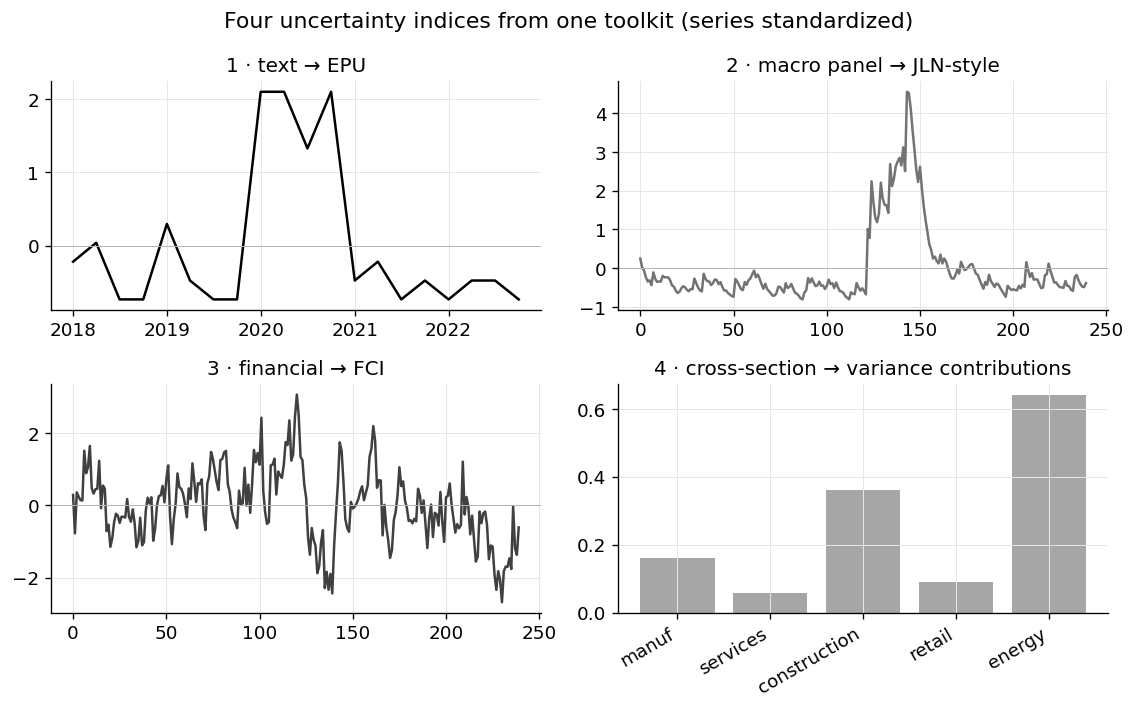

In [6]:
cols = _nbstyle.palette(4)
def _z(s):
    s = np.asarray(s, dtype=float)
    return (s - np.nanmean(s)) / np.nanstd(s)

fig, axes = plt.subplots(2, 2, figsize=(9.6, 6.0))
axes[0, 0].plot(epu_s.index, _z(epu_s.values), color=cols[0]); axes[0, 0].set_title("1 · text → EPU")
axes[0, 1].plot(U.index, _z(U.values), color=cols[1]); axes[0, 1].set_title("2 · macro panel → JLN-style")
axes[1, 0].plot(fci_idx.index, _z(fci_idx.values), color=cols[2]); axes[1, 0].set_title("3 · financial → FCI")
axes[1, 1].bar(range(len(labels)), S.diag_contrib(w), color=cols[3])
axes[1, 1].set_xticks(range(len(labels))); axes[1, 1].set_xticklabels(labels, rotation=30, ha="right")
axes[1, 1].set_title("4 · cross-section → variance contributions")
for ax in axes.flat[:3]:
    ax.axhline(0, color="0.7", linewidth=0.6)
fig.suptitle("Four uncertainty indices from one toolkit (series standardized)")
plt.tight_layout()
plt.show()

## One toolkit, four indices

| You have… | The kernel | puremacro entry point |
|---|---|---|
| a text corpus | three-group co-occurrence | `narrative.indices.epu` (also `mpu`, `lui`, `tone`) |
| a macro panel | common factors + conditional volatility | `factor.pca_factors` → `garch.garch11_fit` |
| financial indicators | first principal component, sign-normalized | `gar.fci` |
| a cross-section of volatilities | the $\sigma\!\cdot\! R$ quadratic form | `sigma.SigmaObject` |

Every uncertainty index in the library is one of these moves. Pick the data you have, pick
the matching kernel, normalize — and you have a research-grade index, in the browser, at \$0.
To go deeper on the text kernel, see **Notebook 11**.